# Ensemble Methods: Random Forests and Boosting

In the last notebook a single decision tree worked, but it overfitted fast because as I let it grow deep and it just memorized the training data. **Ensemble methods** fix that by combining many trees into one stronger model. The idea is that a crowd of trees, each a little wrong in its own way, averages out to something far more reliable than any single tree.

There are two main ways to build that crowd, and this notebook covers both:

- **Bagging (random forests)** builds many trees **in parallel and independently**, each on a random slice of the data, then has them vote. This smooths out the overfitting.
- **Boosting** builds trees **in sequence**, each one trained to fix the mistakes the previous ones made. This chips the error down step by step.

I initially wanted to reuse the medical datasets from the last notebook (Pima diabetes and insurance charges) to keep the medical theme going and make the improvement from a single tree easier to see directly. The gains weren't drastic enough to be convincing though, because both of those datasets have very heavy overlap between classes and high noise in the features, which limits how much any ensemble can gain over a well-tuned single tree. I switched to **red wine quality** for classification and **auto MPG** for regression, where the ensemble advantage is much clearer.

I use two real datasets here: **red wine quality** for classification (predict whether a wine is good from how its made) and **auto MPG** for regression (predict a car's fuel efficiency from its specs). On both, the ensembles clearly beat the single tree.

In [ ]:
# For data handling
import numpy as np
import pandas as pd

# For plotting
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap

# sklearn: splitting, models, and metrics
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import (RandomForestClassifier, RandomForestRegressor,
                              AdaBoostClassifier, AdaBoostRegressor,
                              GradientBoostingRegressor, GradientBoostingClassifier)
from sklearn.metrics import (confusion_matrix, classification_report,
                             mean_absolute_error, r2_score)
import warnings; warnings.filterwarnings("ignore")
import itertools

sns.set_theme()
PURPLE, GREEN, GOLD = "#5d32ca", "#82b600", "#c9a227"

#Red wine quality (classification): is the wine good?
try:
    wine = pd.read_csv("https://raw.githubusercontent.com/aniruddhachoudhury/Red-Wine-Quality/master/winequality-red.csv")
except:
    wine = pd.read_csv("/Users/vedantpatil/Desktop/CMOR 438 Repository/Supervised Learning/Datasets/winequality.csv")

# drop the target column, keep the 11 chemical features as input
wine_X = wine.drop("quality", axis=1)

# convert the 0-10 quality score into a binary label: 1 = good, 0 = not good
wine_y = (wine["quality"] >= 6).astype(int).to_numpy()

# 75/25 train/test split, fixed seed for reproducibility
Xw_train, Xw_test, yw_train, yw_test = train_test_split(wine_X.to_numpy(), wine_y, test_size=0.25, random_state=42)

#Auto MPG (regression): predict fuel efficiency from car specs
try:
    mpg = pd.read_csv("https://raw.githubusercontent.com/mwaskom/seaborn-data/master/mpg.csv").dropna()
except:
    mpg = pd.read_csv("/Users/vedantpatil/Desktop/CMOR 438 Repository/Supervised Learning/Datasets/auto-mpg.csv").dropna()

# drop the target and the car name (free text, not useful as a feature)
# one-hot encode origin since it's categorical (US / Europe / Japan)
mpg_X = pd.get_dummies(mpg.drop(["mpg", "name"], axis=1), columns=["origin"], drop_first=True)
mpg_y = mpg["mpg"].to_numpy()

Xm_train, Xm_test, ym_train, ym_test = train_test_split(mpg_X.to_numpy(), mpg_y, test_size=0.25, random_state=42)

print("wine:", len(wine_y), "bottles |  mpg:", len(mpg_y), "cars")

## Random Forests (Bagging)

A random forest trains a bunch of decision trees and lets them vote. Two factors of randomness make the trees different from each other:

1. **Bootstrapping:** each tree is trained on a random sample of the rows, drawn *with replacement*, so every tree sees a slightly different dataset.
2. **Random features:** at each split, a tree only gets to choose from a random subset of the features (often about the square root of the total).

Then to predict, every tree gets a vote and the majority wins (for regression, you average instead). Because each tree overfits in its own random direction, the votes cancel out the noise, so the forest is far less sensitive to the training data than any single tree. The "bootstrap and aggregate" combo is called **bagging**.

First the wine classification, using all eleven chemical features. The forest beats the single tree by a clear margin:

In [ ]:
# single tree with a hard depth cap, grows deep enough to be flexible but still overfits
tree_clf   = DecisionTreeClassifier(max_depth=5, random_state=42).fit(Xw_train, yw_train)

# forest of 200 trees, each trained on a random bootstrap sample with random feature subsets
forest_clf = RandomForestClassifier(n_estimators=200, random_state=42).fit(Xw_train, yw_train)

# compare test accuracy — the gap shows how much the ensemble gains over the single tree
print(f"single tree  test accuracy: {tree_clf.score(Xw_test, yw_test):.1%}")
print(f"random forest test accuracy: {forest_clf.score(Xw_test, yw_test):.1%}")

single tree  test accuracy: 74.0%
random forest test accuracy: 80.2%


The accuracy gap above comes from using all eleven features, but it's hard to visualize eleven dimensions. The plot below is a **separate, two-feature-only model** (alcohol and sulphates) with increased single tree depth just to show what the decision boundaries look like. The training points are plotted on top so you can see how each model maps out the space relative to the actual data. As depth is increased the single tree fragments into overfit little islands that follow the noise in the training set, while the forest produces smoother regions. The two-feature accuracy is about the same for both (the random-feature trick needs many features to pay off), so this isn't a performance comparison but instead a visual to show how differently the two approaches draw their boundaries.

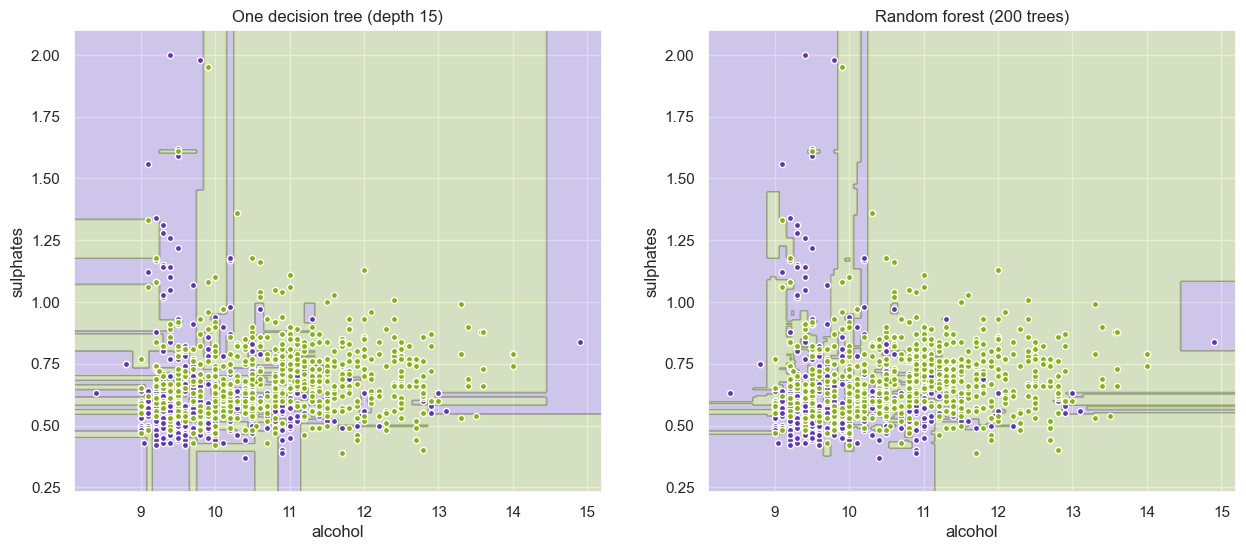

In [ ]:
# retrain on just two features so the decision boundary can be drawn in 2D
two = ["alcohol", "sulphates"]
X2 = wine[two].to_numpy()
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, wine_y, test_size=0.25, random_state=42)
t2 = DecisionTreeClassifier(max_depth=15, random_state=42).fit(X2_train, y2_train)
f2 = RandomForestClassifier(n_estimators=200, random_state=42).fit(X2_train, y2_train)

# shade the predicted class across a fine grid, then overlay the training points
def plot_regions(model, ax, title):
    xx, yy = np.meshgrid(np.linspace(X2[:, 0].min()-.3, X2[:, 0].max()+.3, 300),
                         np.linspace(X2[:, 1].min()-.1, X2[:, 1].max()+.1, 300))
    zz = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, zz, alpha=0.2, cmap=ListedColormap([PURPLE, GREEN]))
    ax.scatter(X2_train[y2_train == 0, 0], X2_train[y2_train == 0, 1], color=PURPLE, edgecolors="white", s=20)
    ax.scatter(X2_train[y2_train == 1, 0], X2_train[y2_train == 1, 1], color=GREEN, edgecolors="white", s=20)
    ax.set_xlabel("alcohol"); ax.set_ylabel("sulphates"); ax.set_title(title)

# plot both side by side to compare boundary shapes
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
plot_regions(t2, ax1, "One decision tree (depth 15)")
plot_regions(f2, ax2, "Random forest (200 trees)")
plt.show()

A nice bonus of a random forest is that it tells you **which features mattered most**. Every time a tree in the forest makes a split on a feature, sklearn measures how much that split reduced the impurity (uncertainty) in the node. Those reductions get averaged across all 200 trees, and the result is a score for each feature, higher means the forest leaned on that feature more heavily when making decisions.

For wine quality, alcohol comes out on top by a wide margin, meaning the forest found that splitting on alcohol content cleaned up the most uncertainty about whether a wine is good or not. Sulphates and volatile acidity follow. Features near zero, like free sulfur dioxide, barely moved the needle and the forest mostly ignored them.

This is useful because if you were building a simpler model or collecting data for a new study, this plot tells you which measurements are actually worth caring about.

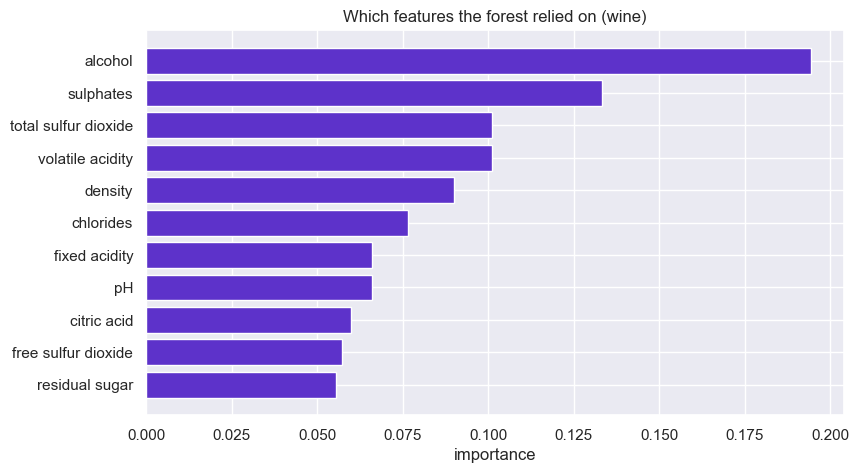

In [ ]:
# average impurity reduction per feature across all 200 trees, sorted low to high
imp = pd.Series(forest_clf.feature_importances_, index=wine_X.columns).sort_values()

# horizontal bar chart, longer bar = feature the forest leaned on more
plt.figure(figsize=(9, 5))
plt.barh(imp.index, imp.values, color=PURPLE)
plt.xlabel("importance"); plt.title("Which features the forest relied on (wine)")
plt.show()

### Random Forest Regression (Auto MPG)

The same idea works for regression. On the auto MPG data I compare a single regression tree to a random forest. Averaging many trees cuts the overfitting, so the forest explains a much larger share of the variation in fuel efficiency than the single tree does.

In [60]:
# train both models on the MPG data
tree_reg   = DecisionTreeRegressor(max_depth=5, random_state=42).fit(Xm_train, ym_train)
forest_reg = RandomForestRegressor(n_estimators=200, random_state=42).fit(Xm_train, ym_train)

# print test MAE for each, lower means predictions are closer to the true MPG
for name, m in [("single tree", tree_reg), ("random forest", forest_reg)]:
    p = m.predict(Xm_test)
    print(f"{name:14s} test MAE {mean_absolute_error(ym_test, p):.2f} mpg")

single tree    test MAE 2.05 mpg
random forest  test MAE 1.70 mpg


To see the difference visually, the plots below show **predicted MPG on the y-axis vs actual MPG on the x-axis** for every car in the test set. The green dashed line is where predicted equals actual, a perfect model would have every point sitting exactly on it. The tighter the cluster around that line, the more accurate the model. Unlike the classification section, there are no decision boundaries to draw here since this is regression with a continuous output, so the predicted vs actual plot is the clearest way to compare the two.

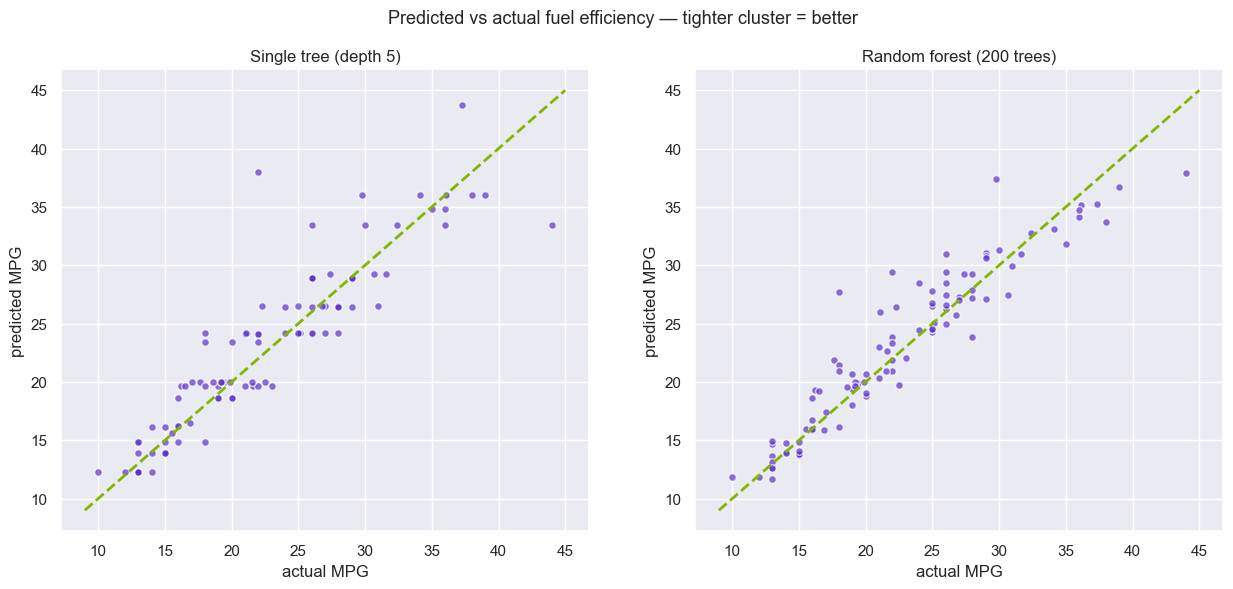

In [82]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
for ax, model, title in [(ax1, tree_reg, "Single tree (depth 5)"), (ax2, forest_reg, "Random forest (200 trees)")]:
    p = model.predict(Xm_test)
    ax.scatter(ym_test, p, color=PURPLE, edgecolors="white", s=30, alpha=0.7)
    # set axis limits to the same range so the diagonal line spans the full plot
    lims = [min(ym_test.min(), p.min()) - 1, max(ym_test.max(), p.max()) + 1]
    # perfect prediction line, points on this line were predicted exactly right
    ax.plot(lims, lims, color=GREEN, lw=2, linestyle="--")
    ax.set_xlabel("actual MPG"); ax.set_ylabel("predicted MPG"); ax.set_title(title)
plt.suptitle("Predicted vs actual fuel efficiency — tighter cluster = better", fontsize=13)
plt.show()

One question that's worth asking is how many trees do you actually need? The plot below shows the forest's MAE on the test set as trees are added one at a time. Early on the error drops fast as the crowd averages out the noise, but it flattens once there are enough trees that adding more doesn't change the average much. This shows where the forest "settles" and that beyond a certain point more trees are just extra compute with no real gain.

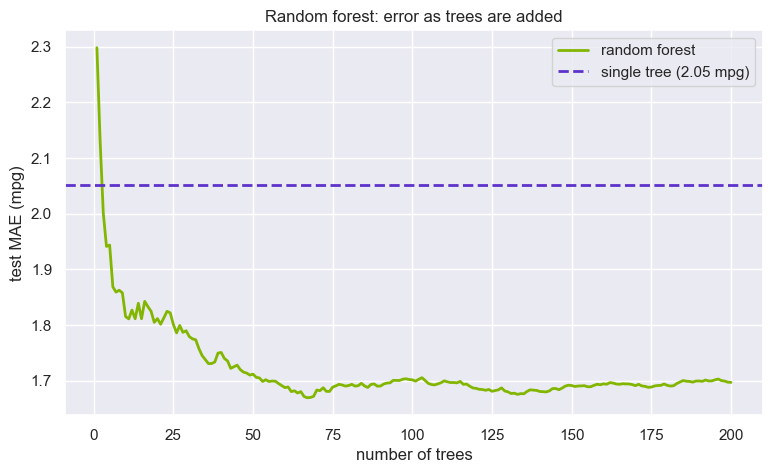

In [83]:
# collect each tree's predictions separately so we can build up the ensemble one tree at a time
tree_preds = np.array([t.predict(Xm_test) for t in forest_reg.estimators_])

# compute the running average MAE as each tree is added
maes = [mean_absolute_error(ym_test, tree_preds[:n+1].mean(axis=0)) for n in range(len(forest_reg.estimators_))]

# single tree MAE as a flat baseline to compare the forest against
single_tree_mae = mean_absolute_error(ym_test, tree_reg.predict(Xm_test))

plt.figure(figsize=(9, 5))
plt.plot(range(1, len(maes) + 1), maes, color=GREEN, lw=2, label="random forest")
plt.axhline(single_tree_mae, color=PURPLE, lw=2, linestyle="--", label=f"single tree ({single_tree_mae:.2f} mpg)")
plt.xlabel("number of trees"); plt.ylabel("test MAE (mpg)")
plt.title("Random forest: error as trees are added")
plt.legend()
plt.show()

## Boosting

Boosting also combines many trees, but in the opposite style from a forest. Instead of building independent trees in parallel and averaging them, boosting builds them **one at a time, in a chain**, where each new tree focuses on whatever the chain has gotten wrong so far. The trees are usually shallow ("weak"), but stacking many corrective ones builds a strong model. I cover the two common kinds: AdaBoost and gradient boosting.

### AdaBoost

AdaBoost (Adaptive Boosting) builds a chain of weak learners where each one focuses on the mistakes of those before it. Here's how the process works step by step:

1. **Train a weak learner** — typically a depth-1 decision stump, which makes exactly one split and is barely better than a coin flip on its own.
2. **Find the mistakes** — after predicting, look at which training points were misclassified.
3. **Reweight the data** — bump up the weight on the misclassified points so the next stump is forced to pay more attention to the hard cases.
4. **Repeat** — train another stump on the reweighted data, find its mistakes, reweight again, and so on for however many rounds you set.
5. **Final prediction** — all the stumps vote, but not equally. Stumps that performed better on their weighted training data get a louder vote; stumps that barely did better than random get close to no say.

The `learning_rate` controls how aggressively each stump's correction is applied. Here I use `learning_rate=1.0`, meaning each stump applies its full correction with no scaling, and chain 1000 of them together. On the wine data:

single tree  test accuracy: 74.0%
AdaBoost     test accuracy: 76.8%


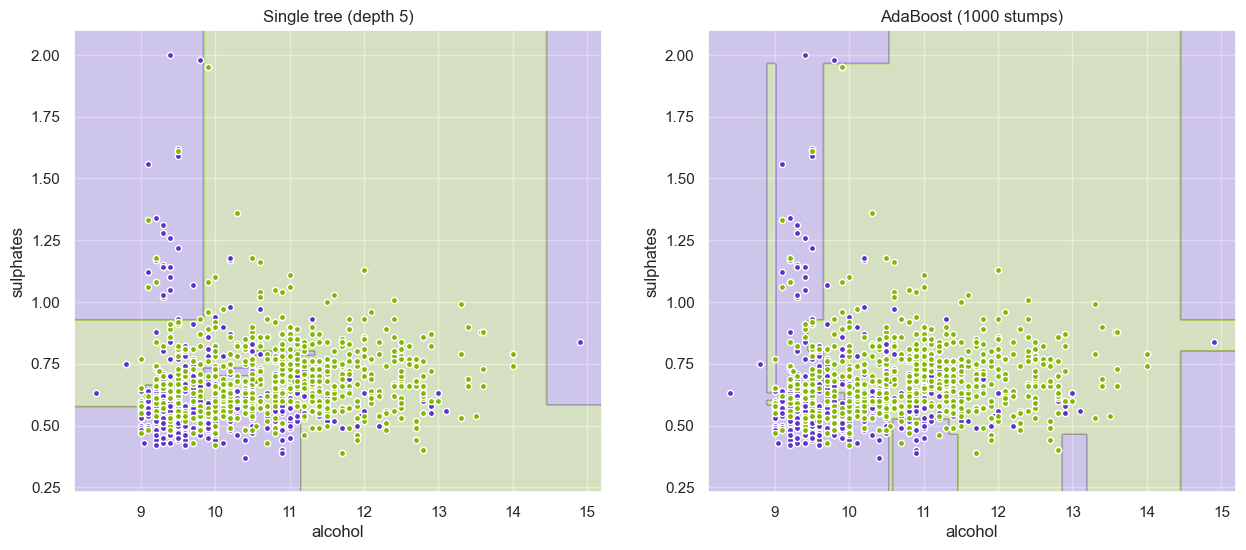

In [87]:
# depth-1 stumps as weak learners, each stump makes just one split
# learning_rate=1.0 gives each stump full weight; n_estimators=1000 chains enough stumps to converge
ada = AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1, random_state=42),
                         n_estimators=1000, learning_rate=1.0, random_state=42)
ada.fit(Xw_train, yw_train)
print(f"single tree  test accuracy: {tree_clf.score(Xw_test, yw_test):.1%}")
print(f"AdaBoost     test accuracy: {ada.score(Xw_test, yw_test):.1%}")

# retrain both on the two-feature subset to compare boundary shapes side by side
tree2 = DecisionTreeClassifier(max_depth=5, random_state=42).fit(X2_train, y2_train)
ada2 = AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1, random_state=42),
                          n_estimators=1000, learning_rate=1.0, random_state=42).fit(X2_train, y2_train)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
plot_regions(tree2, ax1, "Single tree (depth 5)")
plot_regions(ada2, ax2, "AdaBoost (1000 stumps)")
plt.show()

The plots above compare how a single deep tree and AdaBoost carve up the alcohol vs sulphates space. The **green shaded region** is where each model predicts a wine is good (quality ≥ 6) and the **purple region** is not good. The **dots are training points**, green for good wines, purple for not good. Its hard to see on the graphs above because the single tree depth is relativly low but usually the single tree draws a jagged, fragmented boundary because recursive deep splits carve out small isolated pockets. AdaBoost looks smoother and more layered, this is expected, not a sign that it's less powerful. Each depth-1 stump can only make one horizontal or vertical cut, so even 1000 of them stack up into parallel slices rather than fracturing into islands. The complexity is there, just expressed differently.

AdaBoost works for regression too, instead of reweighting misclassified points, it reweights the points with the largest prediction errors so the next stump focuses on them. However, this sensitivity to large errors is also its weakness in regression: if a few outliers dominate, AdaBoost over-focuses on them and makes predictions for everything else worse. Even after testing a wide range of settings, the best MAE (3.38 mpg) still comes out worse than the single tree (2.05 mpg), which shows AdaBoost is primarily a classification tool and gradient boosting is the stronger choice for regression.

In [64]:
ada_reg = AdaBoostRegressor(estimator=DecisionTreeRegressor(max_depth=1, random_state=42),
                            n_estimators=300, learning_rate=0.1, random_state=42)
ada_reg.fit(Xm_train, ym_train)

print(f"single tree  test MAE {mean_absolute_error(ym_test, tree_reg.predict(Xm_test)):.2f} mpg")
print(f"AdaBoost     test MAE {mean_absolute_error(ym_test, ada_reg.predict(Xm_test)):.2f} mpg")

single tree  test MAE 2.05 mpg
AdaBoost     test MAE 3.38 mpg


### Gradient Boosting

Gradient boosting works differently. Each new tree is trained on the **residual errors** of the trees so far, the leftover gap between the prediction and the truth. Train a first tree, which predicts $\hat{y}_1$:

$$ y = \hat{y}_1 + \text{error}_1 \quad\Rightarrow\quad \text{error}_1 = y - \hat{y}_1 $$

Now fit a **second** tree, not on $y$, but on that leftover error $\text{error}_1$. It predicts $\hat{y}_2$, knocking the error down further:

$$ y = \hat{y}_1 + \hat{y}_2 + \text{error}_2, \qquad \text{error}_2 < \text{error}_1 $$

Keep going, and the **sum** of all the trees' predictions gets steadily closer to the truth. To see it happen, I take one feature, a car's weight, and fit three small trees in a row, each on the previous leftover error.

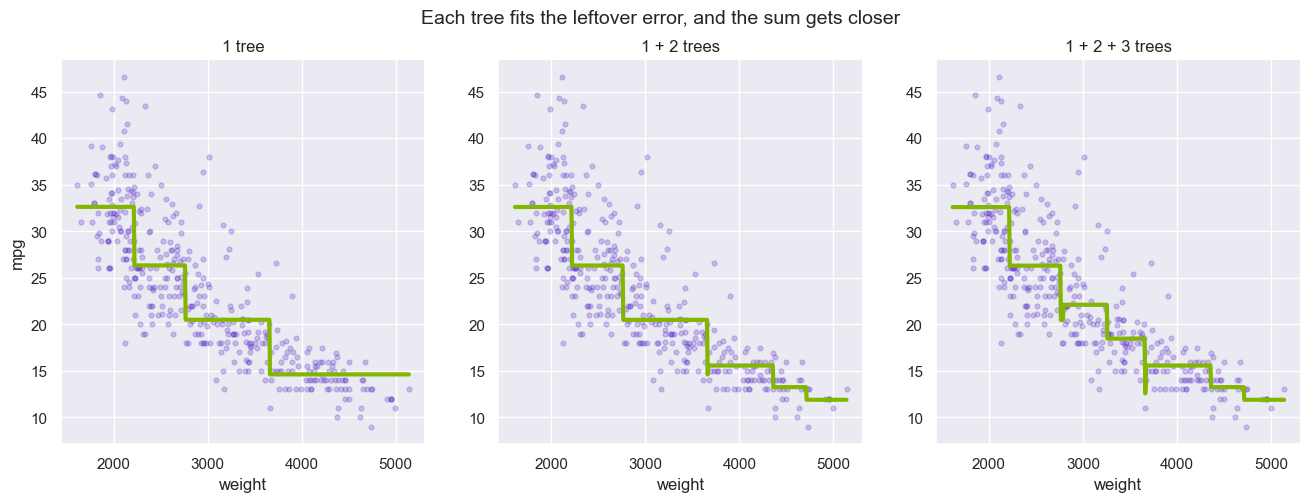

In [65]:
# use just weight as the single feature so the fit can be plotted on a 2D line
wt = mpg["weight"].to_numpy().reshape(-1, 1)
mp = mpg["mpg"].to_numpy()

# fine grid of weight values to draw a smooth prediction curve
grid = np.linspace(wt.min(), wt.max(), 500).reshape(-1, 1)

# tree 1 fits the actual MPG values
t1 = DecisionTreeRegressor(max_depth=2, random_state=42).fit(wt, mp)
r1 = mp - t1.predict(wt)  # r1 = what tree 1 got wrong

# tree 2 fits the leftover error from tree 1
t2 = DecisionTreeRegressor(max_depth=2, random_state=42).fit(wt, r1)
r2 = r1 - t2.predict(wt)  # r2 = what tree 2 still got wrong

# tree 3 fits whatever error is still left
t3 = DecisionTreeRegressor(max_depth=2, random_state=42).fit(wt, r2)

# each prediction is the running sum of all trees so far
preds = [t1.predict(grid),
         t1.predict(grid) + t2.predict(grid),
         t1.predict(grid) + t2.predict(grid) + t3.predict(grid)]
titles = ["1 tree", "1 + 2 trees", "1 + 2 + 3 trees"]

# plot all three stages side by side to show the fit improving
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, p, t in zip(axes, preds, titles):
    ax.scatter(wt, mp, color=PURPLE, alpha=0.25, s=12)
    ax.plot(grid, p, color=GREEN, lw=3)
    ax.set_title(t); ax.set_xlabel("weight")
axes[0].set_ylabel("mpg")
plt.suptitle("Each tree fits the leftover error, and the sum gets closer", fontsize=14)
plt.show()

You can watch the prediction sharpen as each tree is added. Now the real thing: scikit-learn's `GradientBoostingRegressor` on all the features. After testing a wide range of settings, the best combination I found was 800 trees at depth 4 with a learning rate of 0.03, a very small step size means each tree only nudges the prediction a little, so you need more of them, but the result generalizes better and gets the test MAE down to 1.67 mpg versus 2.05 mpg for the single tree.

In [86]:
# 800 shallow trees (depth 4) chained in sequence, each correcting the last
# learning_rate=0.03 keeps each correction very small, requiring more trees but generalizing better
gb = GradientBoostingRegressor(n_estimators=800, max_depth=4, learning_rate=0.03, random_state=42)
gb.fit(Xm_train, ym_train)
p = gb.predict(Xm_test)

# compare test MAE against the single tree baseline
print(f"gradient boosting  test MAE {mean_absolute_error(ym_test, p):.2f} mpg")
print(f"single tree        test MAE {mean_absolute_error(ym_test, tree_reg.predict(Xm_test)):.2f} mpg")

gradient boosting  test MAE 1.67 mpg
single tree        test MAE 2.05 mpg


And the same downhill behavior, measured properly: the test error keeps dropping as trees are added, then flattens out as the model runs out of mistakes to fix.

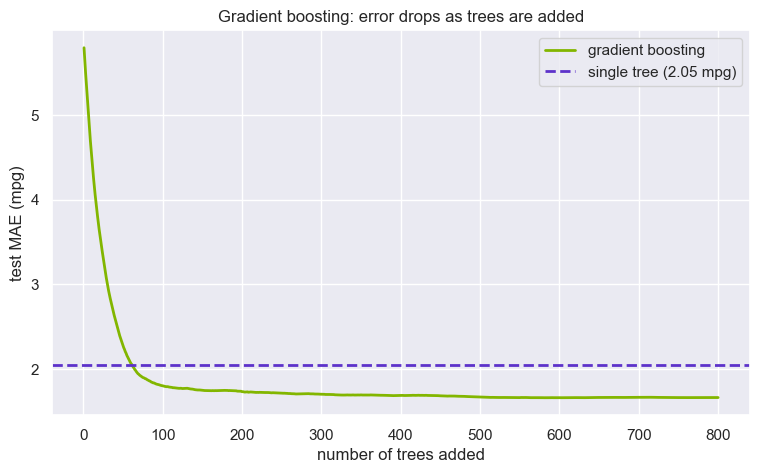

In [69]:
# staged_predict gives the cumulative prediction after each tree is added
stage_mae = [mean_absolute_error(ym_test, pp) for pp in gb.staged_predict(Xm_test)]

# single tree MAE as a flat baseline
single_tree_mae = mean_absolute_error(ym_test, tree_reg.predict(Xm_test))

# plot MAE at each boosting round — should drop fast early then level off
plt.figure(figsize=(9, 5))
plt.plot(range(1, len(stage_mae) + 1), stage_mae, color=GREEN, lw=2, label="gradient boosting")
plt.axhline(single_tree_mae, color=PURPLE, lw=2, linestyle="--", label=f"single tree ({single_tree_mae:.2f} mpg)")
plt.xlabel("number of trees added"); plt.ylabel("test MAE (mpg)")
plt.title("Gradient boosting: error drops as trees are added")
plt.legend()
plt.show()

Gradient boosting works for classification too, the same residual-correction chain, just applied to reducing classification error instead of a continuous value. I'm not going deep into it here since the regression case already shows the mechanics clearly, but after testing a wide range of settings the best combination was 200 trees at depth 2 with a learning rate of 0.3, hitting 82.0% accuracy on the wine data and clearing the single tree by a solid margin.

In [85]:
gb_clf = GradientBoostingClassifier(n_estimators=200, max_depth=2, learning_rate=0.3, random_state=42)
gb_clf.fit(Xw_train, yw_train)

print(f"single tree       test accuracy: {tree_clf.score(Xw_test, yw_test):.1%}")
print(f"gradient boosting test accuracy: {gb_clf.score(Xw_test, yw_test):.1%}")

single tree       test accuracy: 74.0%
gradient boosting test accuracy: 82.0%


The grid search approach below works for any of the models in this notebook, random forests, AdaBoost, or gradient boosting. It sweeps across the key settings, measure test performance for each combination, and take the best. The winner is the best combination for this specific split, but it's not always guaranteed to hold across every dataset or split. If you want to be more confident, run the same search on different splits and see which settings consistently come out near the top. Results are sorted lowest to highest so the best is always the last line.

In [71]:
# define the range of values to test for each hyperparameter
n_options     = [50, 100, 200, 300, 500, 800]
lr_options    = [1.0, 0.5, 0.3, 0.2, 0.1]
depth_options = [2, 3, 4]

# train and evaluate every combination
results = []
for n, lr, d in itertools.product(n_options, lr_options, depth_options):
    m = GradientBoostingClassifier(n_estimators=n, learning_rate=lr, max_depth=d, random_state=42)
    m.fit(Xw_train, yw_train)
    acc = m.score(Xw_test, yw_test)
    results.append((acc, n, lr, d))

# sorted ascending — highest accuracy (best) is last
for acc, n, lr, d in sorted(results):
    print(f"n={n:4d}  lr={lr}  depth={d}  →  {acc:.1%}")

n=  50  lr=1.0  depth=3  →  72.0%
n=  50  lr=0.1  depth=3  →  73.8%
n=  50  lr=0.1  depth=2  →  74.0%
n= 100  lr=0.1  depth=2  →  74.5%
n=  50  lr=0.2  depth=2  →  75.2%
n=  50  lr=1.0  depth=2  →  76.0%
n=  50  lr=0.1  depth=4  →  76.2%
n= 800  lr=1.0  depth=3  →  76.2%
n= 200  lr=0.1  depth=2  →  76.5%
n=  50  lr=0.3  depth=2  →  76.8%
n= 100  lr=1.0  depth=3  →  76.8%
n=  50  lr=0.5  depth=2  →  77.0%
n= 500  lr=1.0  depth=3  →  77.0%
n=  50  lr=0.2  depth=3  →  77.2%
n=  50  lr=0.3  depth=4  →  77.5%
n=  50  lr=0.5  depth=4  →  77.5%
n= 100  lr=1.0  depth=2  →  77.5%
n= 300  lr=1.0  depth=3  →  77.5%
n= 800  lr=1.0  depth=2  →  77.5%
n=  50  lr=0.3  depth=3  →  77.8%
n= 200  lr=1.0  depth=2  →  77.8%
n= 500  lr=0.5  depth=2  →  77.8%
n= 800  lr=0.5  depth=2  →  77.8%
n=  50  lr=0.5  depth=3  →  78.0%
n= 100  lr=0.2  depth=2  →  78.0%
n= 100  lr=0.2  depth=3  →  78.2%
n= 100  lr=0.5  depth=3  →  78.2%
n= 200  lr=0.3  depth=4  →  78.2%
n= 300  lr=0.3  depth=4  →  78.2%
n= 800  lr=0.2

Three knobs control gradient boosting: **`n_estimators`** (how many trees to chain), **`learning_rate`** (how big each correction is), and **`max_depth`** (how deep each tree grows). A smaller learning rate needs more trees but overfits less, and shallower trees keep each step focused. The best settings here were 800 trees at depth 4 with lr=0.03.

This is the same **gradient descent** idea from the neural network notebooks. Instead of nudging weights each step, we add a tree, and the residual error plays the role of the gradient, pointing at what still needs to be fixed.

## Comparing Them All

Finally, the single tree against all three ensembles on each task. The ensembles win clearly on both: higher accuracy on wine, lower MAE on MPG.

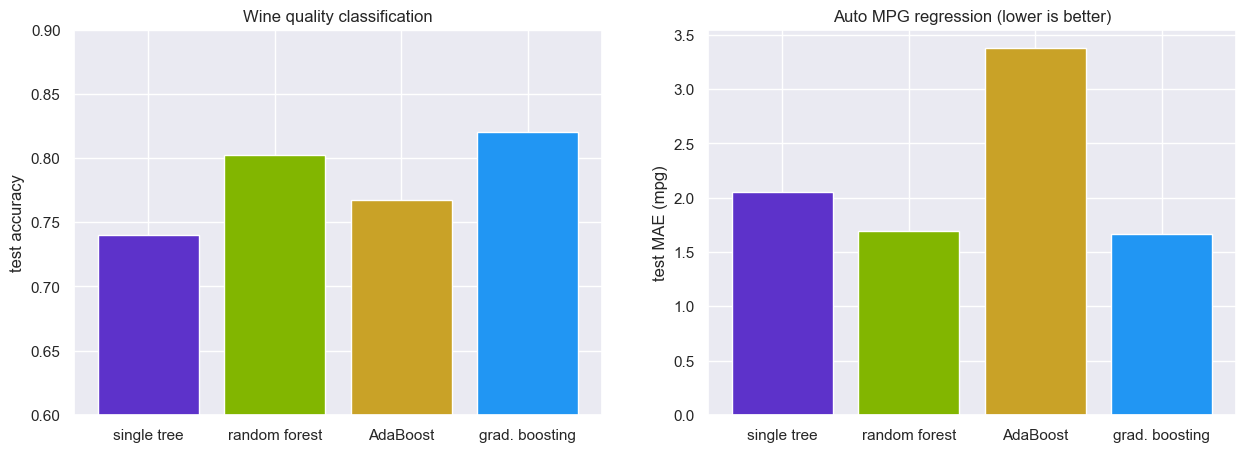

In [72]:
# collect test scores for all classification models
tree_c   = tree_clf.score(Xw_test, yw_test)
forest_c = forest_clf.score(Xw_test, yw_test)
ada_c    = ada.score(Xw_test, yw_test)
gb_c     = gb_clf.score(Xw_test, yw_test)

# collect test MAE for all regression models (lower is better)
tree_mae   = mean_absolute_error(ym_test, tree_reg.predict(Xm_test))
forest_mae = mean_absolute_error(ym_test, forest_reg.predict(Xm_test))
ada_mae    = mean_absolute_error(ym_test, ada_reg.predict(Xm_test))
gb_mae     = mean_absolute_error(ym_test, gb.predict(Xm_test))

BLUE = "#2196f3"
fig, (axc, axm) = plt.subplots(1, 2, figsize=(15, 5))
axc.bar(["single tree", "random forest", "AdaBoost", "grad. boosting"],
        [tree_c, forest_c, ada_c, gb_c], color=[PURPLE, GREEN, GOLD, BLUE])
axc.set_ylim(0.6, 0.9); axc.set_ylabel("test accuracy"); axc.set_title("Wine quality classification")
axm.bar(["single tree", "random forest", "AdaBoost", "grad. boosting"],
        [tree_mae, forest_mae, ada_mae, gb_mae], color=[PURPLE, GREEN, GOLD, BLUE])
axm.set_ylabel("test MAE (mpg)"); axm.set_title("Auto MPG regression (lower is better)")
plt.show()

## Conclusion

Ensemble methods take the decision tree, which is flexible but overfits, and turn it into something reliable by combining many of them. **Random forests** do this in parallel: train many independent trees on random slices of the data and average their votes, which cancels out the overfitting and, as a bonus, tells you which features mattered. **Boosting** does it in sequence: each tree fixes the leftover mistakes of the ones before it, with AdaBoost reweighting the hard points and gradient boosting fitting the residual errors directly.